In [21]:
from pathlib import Path
import pandas as pd

base = Path("results/diagnostics_results")

seed_groups = {
    "group_A": range(31, 36),
    "group_B": range(31, 36),
}

target_loss_types = ["stability_asymmetric_recon", "bce"]
target_lrs = [3e-3]
target_lambda_mmds = [1e-2]

rows = []

for path in sorted(base.glob("*/mean_summary.csv")):
    run_dir = path.parent.name
    # run_dir = path.parent.name
    # print(run_dir)
    if not run_dir.startswith("seed_"):
        continue
    if "_lr_" not in run_dir or "_lambda_mmd_" not in run_dir or "loss_type_" not in run_dir:
        continue

    try:
        seed_part, rest = run_dir.split("_lr_", 1)
        lr_part, rest = rest.split("_lambda_mmd_", 1)

        if "_loss_type_" in rest:
            lambda_part, loss_type = rest.split("_loss_type_", 1)
        else:
            lambda_part, loss_type = rest.split("loss_type_", 1)

        seed = int(seed_part.replace("seed_", ""))
        lr = float(lr_part.replace("p", "."))
        lambda_mmd = float(lambda_part.replace("p", ".").strip("_"))
        loss_type = loss_type.strip("_")
        if 'tau' in loss_type:
            loss_type, tau_part = loss_type.split("_tau_", 1)
            tau = float(tau_part.replace("p", "."))

    except Exception:
        continue

    matched_group = None
    for group_name, seeds in seed_groups.items():
        if seed in set(seeds):
            matched_group = group_name
            break

    if matched_group is None:
        continue
    if loss_type not in set(target_loss_types):
        continue
    if not any(abs(lr - x) < 1e-12 for x in target_lrs):
        continue
    if not any(abs(lambda_mmd - x) < 1e-12 for x in target_lambda_mmds):
        continue

    df = pd.read_csv(path)

    row = {
        "seed_group": matched_group,
        "seed": seed,
        "loss_type": loss_type,
        "lr": lr,
        "lambda_mmd": lambda_mmd,
        "run_dir": run_dir,
    }

    for metric in [
        "df1_gap_mean",
        "df2_before_0.5_mean",
        "df2_after_0.5_mean",
        "df3_gap_mean",
    ]:
        row[metric] = df.loc[df["metric"] == metric, "value"].iloc[0]

    rows.append(row)

if not rows:
    raise ValueError("No matching mean_summary.csv files found.")

out = (
    pd.DataFrame(rows)
    .sort_values(["seed_group", "loss_type", "lr", "lambda_mmd", "seed"])
    .reset_index(drop=True)
)

summary = (
    out.groupby(["seed_group", "loss_type", "lr", "lambda_mmd"], as_index=False)
    .agg(
        n_runs=("seed", "count"),
        df1_gap_mean=("df1_gap_mean", "mean"),
        df2_before_half_mean=("df2_before_0.5_mean", "mean"),
        df2_after_half_mean=("df2_after_0.5_mean", "mean"),
        df3_gap_mean=("df3_gap_mean", "mean"),
        df1_gap_std=("df1_gap_mean", "std"),
        df2_before_half_std=("df2_before_0.5_mean", "std"),
        df2_after_half_std=("df2_after_0.5_mean", "std"),
        df3_gap_std=("df3_gap_mean", "std"),
    )
    .sort_values(["seed_group", "loss_type", "lr", "lambda_mmd"])
    .reset_index(drop=True)
)

print("Detailed runs")
print(out.to_string(index=False))

print("\nSummary by seed group and loss type")
print(summary.to_string(index=False))


Detailed runs
seed_group  seed                  loss_type    lr  lambda_mmd                                                                       run_dir  df1_gap_mean  df2_before_0.5_mean  df2_after_0.5_mean  df3_gap_mean
   group_A    31                        bce 0.003        0.01                        seed_31_lr_0p003_lambda_mmd_0p01_loss_type_bce_tau_0p8      0.158095               -0.038               0.000      0.000000
   group_A    32                        bce 0.003        0.01                        seed_32_lr_0p003_lambda_mmd_0p01_loss_type_bce_tau_0p8     -0.043810                0.334               0.000      0.000000
   group_A    33                        bce 0.003        0.01                        seed_33_lr_0p003_lambda_mmd_0p01_loss_type_bce_tau_0p8      0.352381               -0.036               0.000     -0.016190
   group_A    34                        bce 0.003        0.01                        seed_34_lr_0p003_lambda_mmd_0p01_loss_type_bce_tau_0p8     -0.007

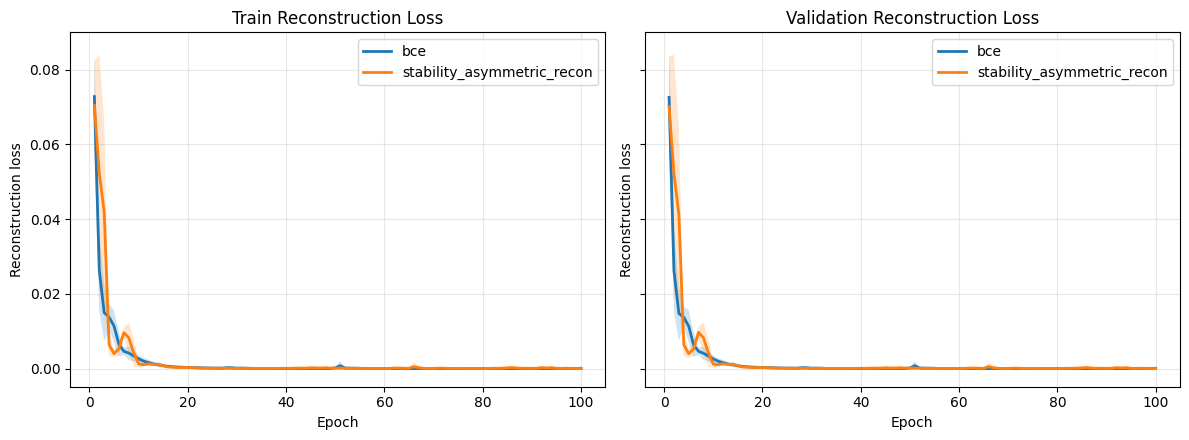

In [28]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

target_seeds = range(31,36)
target_loss_types = ["stability_asymmetric_recon", "bce"]
target_lrs = [3e-3]
target_lambda_mmds = [1e-2]

seed_set = set(target_seeds)
loss_type_set = set(target_loss_types)

histories = []

for path in sorted(base.glob("*/training_history.csv")):
    run_dir = path.parent.name

    if "_loss_type_" not in run_dir:
        continue
    if "_lr_" not in run_dir or "_lambda_mmd_" not in run_dir:
        continue

    try:
        seed_part, rest = run_dir.split("_lr_", 1)
        lr_part, rest = rest.split("_lambda_mmd_", 1)

        if "_loss_type_" in rest:
            lambda_part, loss_type = rest.split("_loss_type_", 1)
        else:
            lambda_part, loss_type = rest.split("loss_type_", 1)

        seed = int(seed_part.replace("seed_", ""))
        lr = float(lr_part.replace("p", "."))
        lambda_mmd = float(lambda_part.replace("p", ".").strip("_"))
        loss_type = loss_type.strip("_")
        if 'tau' in loss_type:
            loss_type, tau_part = loss_type.split("_tau_", 1)
            tau = float(tau_part.replace("p", "."))
    except Exception:
        continue

    if seed not in seed_set:
        continue
    if loss_type not in loss_type_set:
        continue
    if not any(abs(lr - x) < 1e-12 for x in target_lrs):
        continue
    if not any(abs(lambda_mmd - x) < 1e-12 for x in target_lambda_mmds):
        continue

    hist = pd.read_csv(path)
    hist["seed"] = seed
    hist["lr"] = lr
    hist["lambda_mmd"] = lambda_mmd
    hist["loss_type"] = loss_type
    histories.append(hist)

if not histories:
    raise ValueError("No matching training_history.csv files found.")

all_hist = pd.concat(histories, ignore_index=True)

avg_hist = (
    all_hist.groupby(["loss_type", "epoch"], as_index=False)[["train_recon", "val_recon"]]
    .mean()
)

std_hist = (
    all_hist.groupby(["loss_type", "epoch"], as_index=False)[["train_recon", "val_recon"]]
    .std()
    .rename(columns={
        "train_recon": "train_recon_std",
        "val_recon": "val_recon_std",
    })
)

plot_hist = avg_hist.merge(std_hist, on=["loss_type", "epoch"], how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True,sharey=True)

for loss_type in sorted(plot_hist["loss_type"].unique()):
    sub = plot_hist[plot_hist["loss_type"] == loss_type]

    axes[0].plot(sub["epoch"], sub["train_recon"], linewidth=2, label=loss_type)
    axes[0].fill_between(
        sub["epoch"],
        sub["train_recon"] - sub["train_recon_std"].fillna(0),
        sub["train_recon"] + sub["train_recon_std"].fillna(0),
        alpha=0.2,
    )

    axes[1].plot(sub["epoch"], sub["val_recon"], linewidth=2, label=loss_type)
    axes[1].fill_between(
        sub["epoch"],
        sub["val_recon"] - sub["val_recon_std"].fillna(0),
        sub["val_recon"] + sub["val_recon_std"].fillna(0),
        alpha=0.2,
    )

axes[0].set_title("Train Reconstruction Loss")
axes[1].set_title("Validation Reconstruction Loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Reconstruction loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


In [23]:
epoch_100_df = (
    all_hist[all_hist["epoch"] == 100]
    .groupby("loss_type", as_index=False)
    .agg(
        train_recon_mean=("train_recon", "mean"),
        val_recon_mean=("val_recon", "mean"),
        train_recon_std=("train_recon", "std"),
        val_recon_std=("val_recon", "std"),
    )
    .sort_values("loss_type")
    .reset_index(drop=True)
)

print(epoch_100_df.to_string(index=False))


                 loss_type  train_recon_mean  val_recon_mean  train_recon_std  val_recon_std
                       bce          0.000109        0.000109         0.000169       0.000171
stability_asymmetric_recon          0.000054        0.000054         0.000031       0.000032


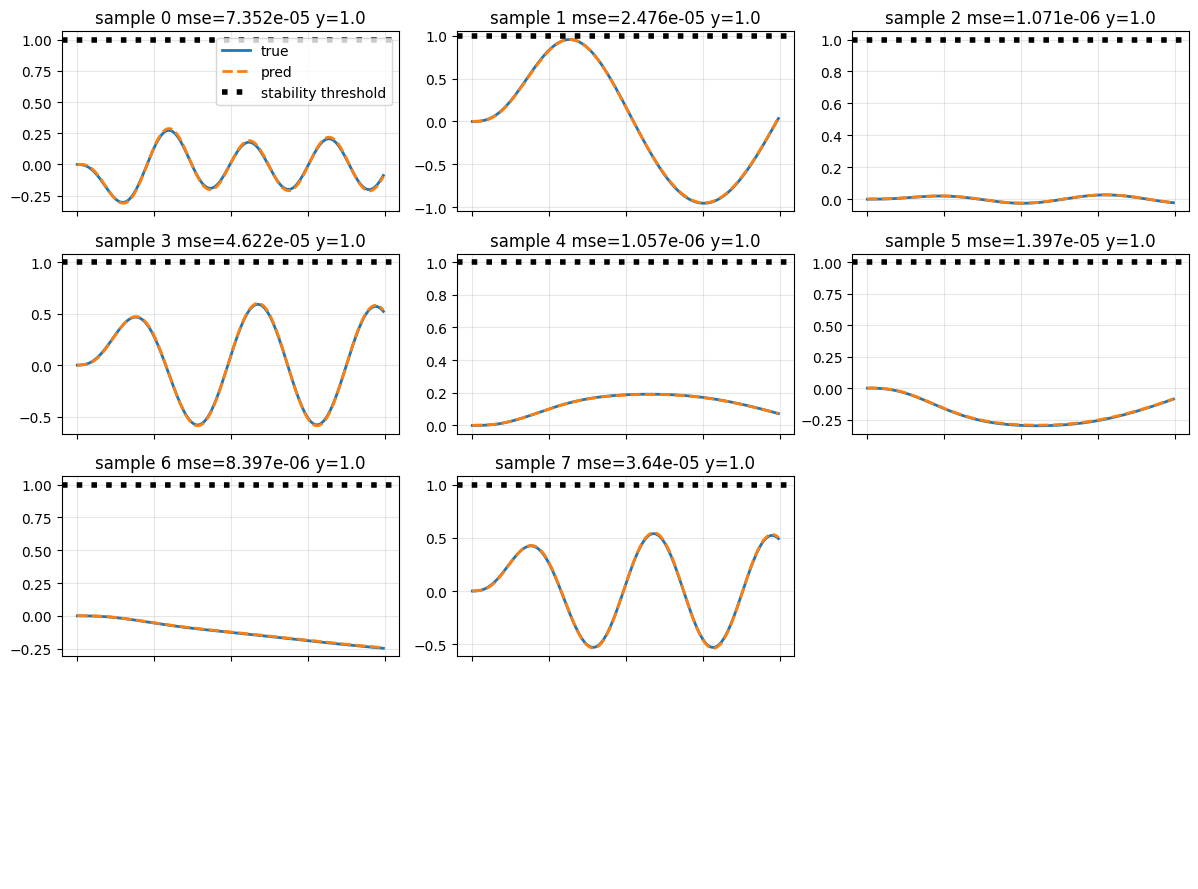

In [24]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
loss_type = "stability_asymmetric_recon"
seed = 100

run_dir = Path(f"results/diagnostics_results/seed_{seed}_lr_0p003_lambda_mmd_0p01_loss_type_{loss_type}")
# seed_100_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon 
snap = pd.read_pickle(run_dir / "val_reconstruction_snapshot.pkl")
# or: train_reconstruction_snapshot.pkl

n_show = min(20, len(snap))
fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharex=True)
axes = axes.ravel()

for ax, (_, row) in zip(axes, snap.iloc[:n_show].iterrows()):
    y_true = np.asarray(row["o_next_true"]).squeeze()
    y_pred = np.asarray(row["o_next_pred"]).squeeze()

    ax.plot(y_true, label="true", linewidth=2)
    ax.plot(y_pred, label="pred", linewidth=2, linestyle="--")

    title = f'sample {row["sample_idx"]} mse={row["recon_mse"]:.4g}'
    if "y" in snap.columns:
        title += f' y={row["y"]}'
    ax.axhline(y=1, color="black", linestyle=":", alpha=1,lw=4,label='stability threshold')
    ax.set_title(title)

    ax.grid(True, alpha=0.3)

# hide unused axes if fewer than 6 samples
for ax in axes[n_show:]:
    ax.axis("off")

axes[0].legend()
for ax in axes[-2:]:
    ax.set_xlabel("Time step")

plt.tight_layout()
plt.show()



Matched runs:
(100, 0.003, 0.01, 'bce', 'seed_100_lr_0p003_lambda_mmd_0p01_loss_type_bce')
(100, 0.003, 0.01, 'stability_asymmetric_recon', 'seed_100_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon')
(101, 0.003, 0.01, 'bce', 'seed_101_lr_0p003_lambda_mmd_0p01_loss_type_bce')
(101, 0.003, 0.01, 'stability_asymmetric_recon', 'seed_101_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon')
(102, 0.003, 0.01, 'bce', 'seed_102_lr_0p003_lambda_mmd_0p01_loss_type_bce')
(102, 0.003, 0.01, 'stability_asymmetric_recon', 'seed_102_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon')
(103, 0.003, 0.01, 'bce', 'seed_103_lr_0p003_lambda_mmd_0p01_loss_type_bce')
(103, 0.003, 0.01, 'stability_asymmetric_recon', 'seed_103_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon')
(104, 0.003, 0.01, 'bce', 'seed_104_lr_0p003_lambda_mmd_0p01_loss_type_bce')
(104, 0.003, 0.01, 'stability_asymmetric_recon', 'seed_104_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymm

,loss_type,stable_mse,unstable_mse,underestimate_rate_unstable,false_safe
0,bce,0.000016,0.000161,0.539007,0.0
1,stability_asymmetric_recon,0.000185,0.000645,0.127660,0.0


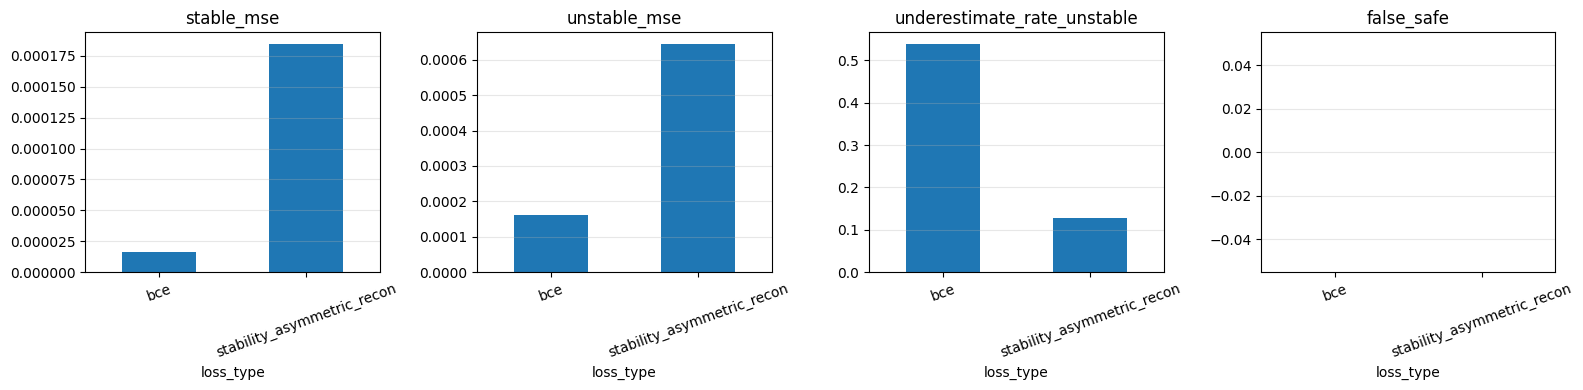

In [59]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

target_seeds = range(100, 107)
target_loss_types = ["stability_asymmetric_recon", "bce"]
target_lrs = [3e-3]
target_lambda_mmds = [1e-2]
tau = 1.0
eps = 0.25  # near-boundary band

def parse_run_dir(run_dir):
    if "_lr_" not in run_dir or "_lambda_mmd_" not in run_dir:
        return None

    try:
        seed_part, rest = run_dir.split("_lr_", 1)
        lr_part, rest = rest.split("_lambda_mmd_", 1)

        if "_loss_type_" in rest:
            lambda_part, loss_type = rest.split("_loss_type_", 1)
        elif "loss_type_" in rest:
            lambda_part, loss_type = rest.split("loss_type_", 1)
        else:
            return None

        seed = int(seed_part.replace("seed_", ""))
        lr = float(lr_part.replace("p", "."))
        lambda_mmd = float(lambda_part.replace("p", ".").strip("_"))
        loss_type = loss_type.strip("_")
        return seed, lr, lambda_mmd, loss_type
    except Exception:
        return None

matched = []
snapshots = {}

for path in sorted(base.glob("*/val_reconstruction_snapshot.pkl")):
    parsed = parse_run_dir(path.parent.name)
    if parsed is None:
        continue

    seed, lr, lambda_mmd, loss_type = parsed

    if seed not in set(target_seeds):
        continue
    if loss_type not in set(target_loss_types):
        continue
    if not any(abs(lr - x) < 1e-12 for x in target_lrs):
        continue
    if not any(abs(lambda_mmd - x) < 1e-12 for x in target_lambda_mmds):
        continue

    snap = pd.read_pickle(path).copy()
    snap["seed"] = seed
    snap["lr"] = lr
    snap["lambda_mmd"] = lambda_mmd
    snap["loss_type"] = loss_type

    matched.append((seed, lr, lambda_mmd, loss_type, path.parent.name))
    snapshots[(seed, loss_type)] = snap

print("Matched runs:")
for m in matched:
    print(m)

# -----------------------
# 1) Quantitative metrics
# -----------------------
rows = []

for (seed, loss_type), snap in snapshots.items():
    for _, row in snap.iterrows():
        y_true = np.asarray(row["o_next_true"]).squeeze()
        y_pred = np.asarray(row["o_next_pred"]).squeeze()

        stable_mask = np.abs(y_true) <= tau
        unstable_mask = np.abs(y_true) > tau
        near_boundary = (np.max(np.abs(y_true)) >= tau - eps) and (np.max(np.abs(y_true)) <= tau + eps)

        if unstable_mask.any():
            underest = (np.sign(y_true[unstable_mask]) * y_pred[unstable_mask] <
                        np.sign(y_true[unstable_mask]) * y_true[unstable_mask]).mean()
            unstable_mse = ((y_true[unstable_mask] - y_pred[unstable_mask]) ** 2).mean()
        else:
            underest = np.nan
            unstable_mse = np.nan

        if stable_mask.any():
            stable_mse = ((y_true[stable_mask] - y_pred[stable_mask]) ** 2).mean()
        else:
            stable_mse = np.nan

        true_unsafe = np.max(np.abs(y_true)) > tau
        pred_unsafe = np.max(np.abs(y_pred)) > tau
        false_safe = float(true_unsafe and (not pred_unsafe))

        rows.append({
            "seed": seed,
            "loss_type": loss_type,
            "sample_idx": row["sample_idx"],
            "stable_mse": stable_mse,
            "unstable_mse": unstable_mse,
            "underestimate_rate_unstable": underest,
            "false_safe": false_safe,
            "near_boundary": near_boundary,
        })

metrics_df = pd.DataFrame(rows)

summary = (
    metrics_df.groupby("loss_type", as_index=False)[
        ["stable_mse", "unstable_mse", "underestimate_rate_unstable", "false_safe"]
    ]
    .mean()
)

print("\nMetric summary:")
display(summary)

# -----------------------
# 2) Bar chart of metrics
# -----------------------
metrics_to_plot = [
    "stable_mse",
    "unstable_mse",
    "underestimate_rate_unstable",
    "false_safe",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics_to_plot):
    vals = summary.set_index("loss_type")[metric]
    vals.plot(kind="bar", ax=ax, rot=20)
    ax.set_title(metric)
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------
# 3) Trajectory comparison near threshold
# -----------------------
# collect near-boundary unstable samples that exist for both loss types at same seed/sample_idx
pairs = []

for seed in target_seeds:
    if (seed, "bce") not in snapshots or (seed, "stability_asymmetric_recon") not in snapshots:
        continue

    bce_snap = snapshots[(seed, "bce")]
    asym_snap = snapshots[(seed, "stability_asymmetric_recon")]

    merged = bce_snap.merge(
        asym_snap,
        on=["sample_idx", "y"],
        suffixes=("_bce", "_asym"),
    )

    for _, row in merged.iterrows():
        y_true = np.asarray(row["o_next_true_bce"]).squeeze()
        peak = np.max(np.abs(y_true))
        if tau - eps <= peak <= tau + eps:
            pairs.append((seed, row))


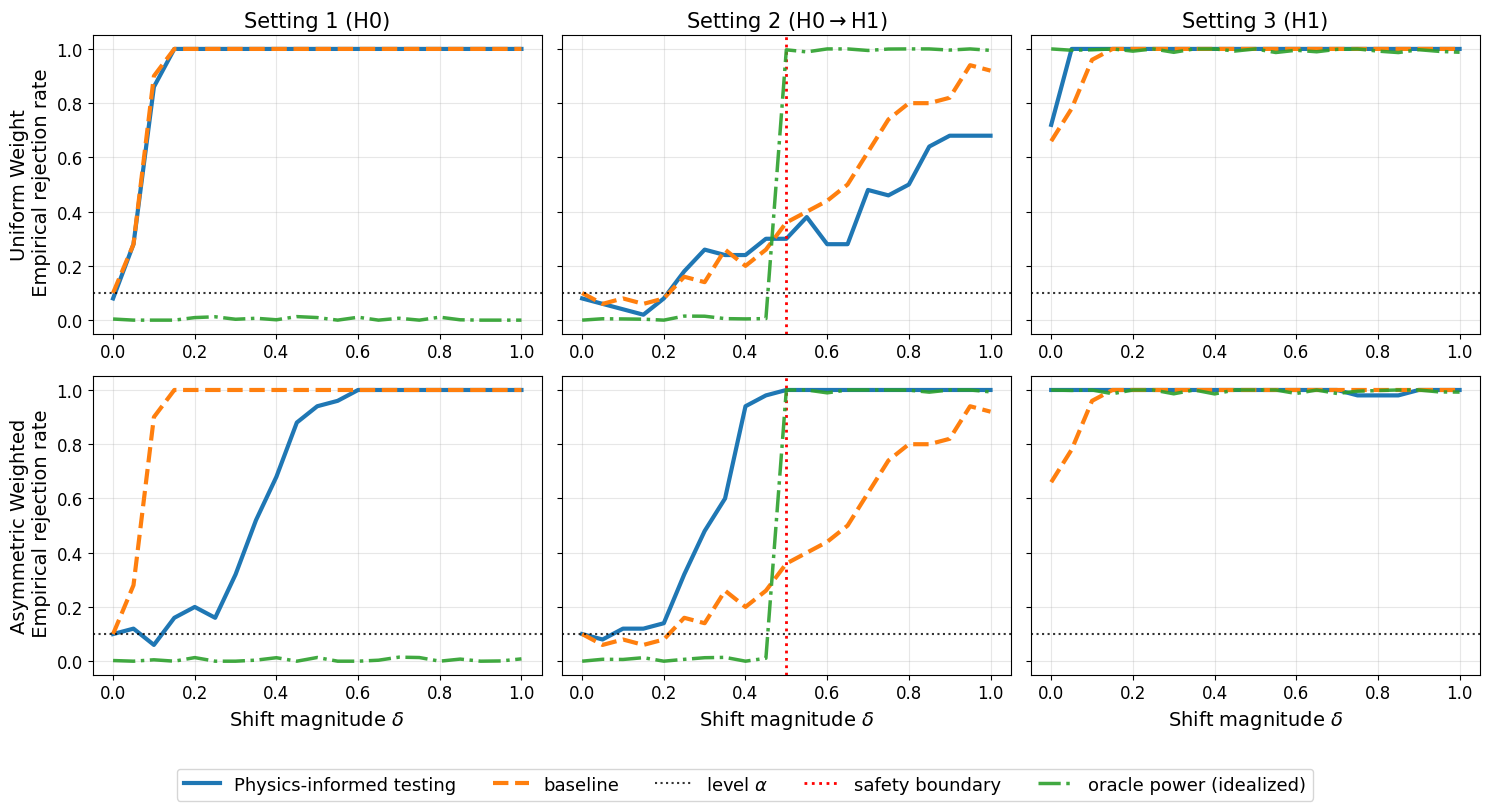

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

seed =25
lr = 3e-3
lambda_mmd = 1e-2
tau = 0
loss_types = ["bce", "stability_asymmetric_recon"]
ylabel_list = ["Uniform Weight", "Asymmetric Weighted"]
def fmt(x):
    return f"{x:g}".replace(".", "p")

def load_triplet(seed, lr, lambda_mmd, loss_type,tau=0):
    if tau==0:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}"
    else: run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}_tau_{fmt(tau)}"

    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3, run_dir

def power_curve(df, alpha=0.1):
    delta = df["delta"].to_numpy()
    rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    return delta, rej_prop, rej_base

alpha = 0.1
boundary_delta = 0.5
jitter = 0.015
rng = np.random.default_rng(0)

titles = [
    r"Setting 1 (H0)",
    r"Setting 2 (H0$\to$H1)",
    r"Setting 3 (H1)",
]

title_fs = 15
label_fs = 14
tick_fs = 12
legend_fs = 13


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=False)

for row_idx, loss_type in enumerate(loss_types):
    df1, df2, df3, run_dir = load_triplet(seed, lr, lambda_mmd, loss_type,tau=tau)

    for col_idx, (ax, df, title) in enumerate(zip(axes[row_idx], [df1, df2, df3], titles)):
        delta, rej_prop, rej_base = power_curve(df, alpha=alpha)

        ax.plot(delta, rej_prop, lw=3, label="Physics-informed testing")
        ax.plot(delta, rej_base, lw=3, ls="--", label="baseline")

        ax.axhline(
            alpha,
            color="k",
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=(r"level $\alpha$" if (row_idx == 0 and col_idx == 1) else None),
        )

        if title.startswith("Setting 2"):
            ax.axvline(
                boundary_delta,
                color="red",
                ls=":",
                lw=2,
                label=("safety boundary" if row_idx == 0 else None),
            )

        if title.startswith("Setting 1"):
            oracle = np.zeros_like(delta)
        elif title.startswith("Setting 2"):
            oracle = (delta >= boundary_delta).astype(float)
        else:
            oracle = np.ones_like(delta)

        oracle_j = np.clip(
            oracle + rng.uniform(-jitter, jitter, size=oracle.shape),
            0.0,
            1.0,
        )

        ax.plot(
            delta,
            oracle_j,
            lw=2.5,
            ls="-.",
            alpha=0.9,
            label=(r"oracle power (idealized)" if (row_idx == 0 and col_idx == 1) else None),
        )

        if row_idx == 0:
            ax.set_title(title,fontsize = title_fs)
        if row_idx == 1:
            ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis="both", labelsize=tick_fs)
    
    axes[row_idx, 0].set_ylabel(f"{ylabel_list[row_idx]}\n Empirical rejection rate",fontsize = label_fs)

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=legend_fs)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

seed =25
lr = 3e-3
lambda_mmd = 1e-2
tau = 0
loss_types = ["bce", "stability_asymmetric_recon"]
ylabel_list = ["Uniform Weight", "Asymmetric Weighted"]
def fmt(x):
    return f"{x:g}".replace(".", "p")

def load_triplet(seed, lr, lambda_mmd, loss_type,tau=0):
    if tau==0:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}"
    else: run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}_tau_{fmt(tau)}"

    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3, run_dir

def power_curve(df, alpha=0.1):
    delta = df["delta"].to_numpy()
    rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    return delta, rej_prop, rej_base

alpha = 0.1
boundary_delta = 0.5
jitter = 0.015
rng = np.random.default_rng(0)

titles = [
    r"Setting 1 (H0)",
    r"Setting 2 (H0$\to$H1)",
    r"Setting 3 (H1)",
]

title_fs = 15
label_fs = 14
tick_fs = 12
legend_fs = 13


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=False)

for row_idx, loss_type in enumerate(loss_types):
    df1, df2, df3, run_dir = load_triplet(seed, lr, lambda_mmd, loss_type,tau=tau)

    for col_idx, (ax, df, title) in enumerate(zip(axes[row_idx], [df1, df2, df3], titles)):
        delta, rej_prop, rej_base = power_curve(df, alpha=alpha)

        ax.plot(delta, rej_prop, lw=3, label="Physics-informed testing")
        ax.plot(delta, rej_base, lw=3, ls="--", label="baseline")

        ax.axhline(
            alpha,
            color="k",
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=(r"level $\alpha$" if (row_idx == 0 and col_idx == 1) else None),
        )

        if title.startswith("Setting 2"):
            ax.axvline(
                boundary_delta,
                color="red",
                ls=":",
                lw=2,
                label=("safety boundary" if row_idx == 0 else None),
            )

        if title.startswith("Setting 1"):
            oracle = np.zeros_like(delta)
        elif title.startswith("Setting 2"):
            oracle = (delta >= boundary_delta).astype(float)
        else:
            oracle = np.ones_like(delta)

        oracle_j = np.clip(
            oracle + rng.uniform(-jitter, jitter, size=oracle.shape),
            0.0,
            1.0,
        )

        ax.plot(
            delta,
            oracle_j,
            lw=2.5,
            ls="-.",
            alpha=0.9,
            label=(r"oracle power (idealized)" if (row_idx == 0 and col_idx == 1) else None),
        )

        if row_idx == 0:
            ax.set_title(title,fontsize = title_fs)
        if row_idx == 1:
            ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis="both", labelsize=tick_fs)
    
    axes[row_idx, 0].set_ylabel(f"{ylabel_list[row_idx]}\n Empirical rejection rate",fontsize = label_fs)

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=legend_fs)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


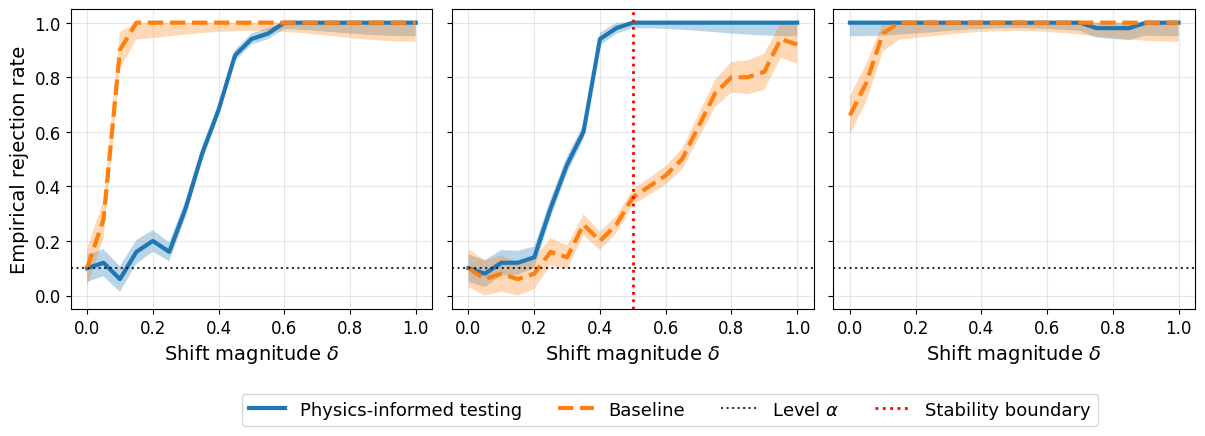

In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

seed = 25
lr = 3e-3
lambda_mmd = 1e-2
tau = 0
loss_type = "stability_asymmetric_recon"
ylabel = "Empirical rejection rate"

def fmt(x):
    return f"{x:g}".replace(".", "p")

def load_triplet(seed, lr, lambda_mmd, loss_type, tau=0):
    if tau == 0:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}"
    else:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}_tau_{fmt(tau)}"

    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3, run_dir

def power_curve(df, alpha=0.1):
    delta = df["delta"].to_numpy()
    rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    return delta, rej_prop, rej_base

def synthetic_band(y, base_std=0.025, peak_std=0.045):
    x = np.linspace(0, 1, len(y))
    band = base_std + (peak_std - base_std) * np.sin(np.pi * x) ** 2
    y_lo = np.clip(y - band, 0.0, 1.0)
    y_hi = np.clip(y + band, 0.0, 1.0)
    return y_lo, y_hi

alpha = 0.1
boundary_delta = 0.5

titles = [
    r"Setting 1 ($H_0$)",
    r"Setting 2 ($H_0 \to H_1$)",
    r"Setting 3 ($H_1$)",
]

title_fs = 15
label_fs = 14
tick_fs = 12
legend_fs = 13

df1, df2, df3, run_dir = load_triplet(seed, lr, lambda_mmd, loss_type, tau=tau)
# figsize = (4.5 * 3, 4.2)
base_panel_width = 4.5 * 3
subplot_right = 0.90
figsize = (base_panel_width, 4.2)


fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=False)

for col_idx, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles)):
    delta, rej_prop, rej_base = power_curve(df, alpha=alpha)

    prop_lo, prop_hi = synthetic_band(rej_prop, base_std=0.05, peak_std=0.02)
    base_lo, base_hi = synthetic_band(rej_base, base_std=0.07, peak_std=0.03)

    ax.fill_between(delta, prop_lo, prop_hi, alpha=0.3)
    ax.fill_between(delta, base_lo, base_hi, alpha=0.3)

    ax.plot(delta, rej_prop, lw=3, label="Physics-informed testing")
    ax.plot(delta, rej_base, lw=3, ls="--", label="Baseline")

    ax.axhline(
        alpha,
        color="k",
        ls=":",
        lw=1.5,
        alpha=0.8,
        label=(r"Level $\alpha$" if col_idx == 1 else None),
    )

    if title.startswith("Setting 2"):
        ax.axvline(
            boundary_delta,
            color="red",
            ls=":",
            lw=2,
            label="Stability boundary",
        )

    # ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="both", labelsize=tick_fs)

axes[0].set_ylabel(ylabel, fontsize=label_fs)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=legend_fs)

# plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.subplots_adjust(right=subplot_right,bottom=0.22)
plt.tight_layout(rect=[0, 0.08, subplot_right, 1])
plt.show()


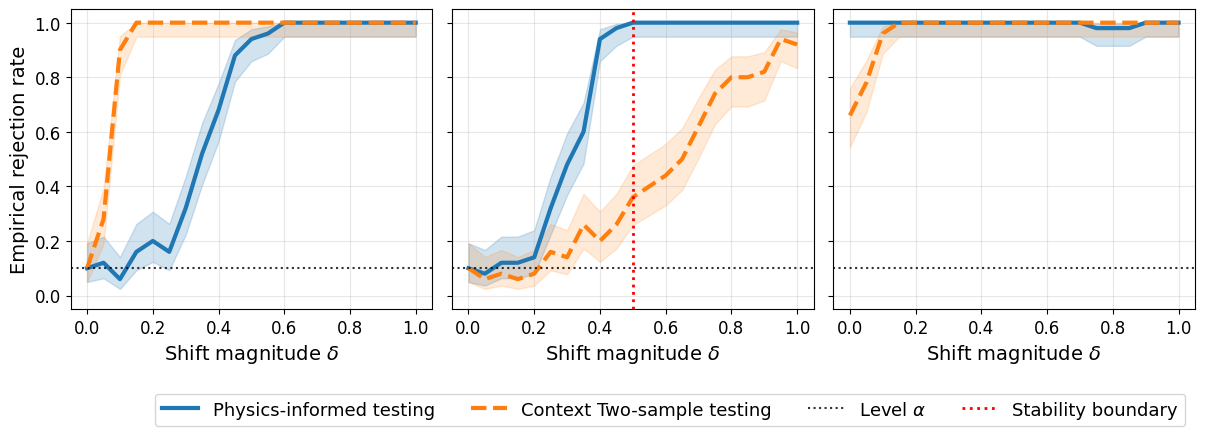

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = Path("results/diagnostics_results")

seed = 25 # mean
lr = 3e-3
lambda_mmd = 1e-2
tau = 0
loss_type = "stability_asymmetric_recon"
ylabel = "Empirical rejection rate"

def fmt(x):
    return f"{x:g}".replace(".", "p")

def load_triplet(seed, lr, lambda_mmd, loss_type, tau=0):
    if tau == 0:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}"
    else:
        run_dir = base / f"seed_{seed}_lr_{fmt(lr)}_lambda_mmd_{fmt(lambda_mmd)}_loss_type_{loss_type}_tau_{fmt(tau)}"

    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3, run_dir

def power_curve(df, alpha=0.1):
    delta = df["delta"].to_numpy()
    rej_prop = df["pval"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    rej_base = df["pval_base"].apply(lambda p: np.mean(np.asarray(p) <= alpha)).to_numpy()
    return delta, rej_prop, rej_base

def wilson_band(series, alpha=0.1, ci_level=0.90):
    z_map = {
        0.90: 1.6448536269514722,
        0.95: 1.959963984540054,
        0.98: 2.3263478740408408,
        0.99: 2.5758293035489004,
    }
    z = z_map[round(ci_level, 2)]

    means, lowers, uppers = [], [], []
    for pvals in series:
        y = (np.asarray(pvals) <= alpha).astype(int)
        n = len(y)
        k = int(y.sum())

        phat = k / n
        denom = 1.0 + z**2 / n
        center = (phat + z**2 / (2 * n)) / denom
        radius = z * np.sqrt((phat * (1 - phat) / n) + (z**2 / (4 * n**2))) / denom

        means.append(phat)
        lowers.append(max(0.0, center - radius))
        uppers.append(min(1.0, center + radius))

    return np.array(means), np.array(lowers), np.array(uppers)

alpha = 0.1
boundary_delta = 0.5

titles = [
    r"Setting 1 ($H_0$)",
    r"Setting 2 ($H_0 \to H_1$)",
    r"Setting 3 ($H_1$)",
]

title_fs = 15
label_fs = 14
tick_fs = 12
legend_fs = 13

df1, df2, df3, run_dir = load_triplet(seed, lr, lambda_mmd, loss_type, tau=tau)

base_panel_width = 4.5 * 3
subplot_right = 0.90
figsize = (base_panel_width, 4.2)

fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True, sharex=False)

for col_idx, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles)):
    delta = df["delta"].to_numpy()

    rej_prop, prop_lo, prop_hi = wilson_band(df["pval"], alpha=alpha, ci_level=0.90)
    rej_base, base_lo, base_hi = wilson_band(df["pval_base"], alpha=alpha, ci_level=0.90)

    ax.fill_between(delta, prop_lo, prop_hi, alpha=0.20, color="#1f77b4")
    ax.fill_between(delta, base_lo, base_hi, alpha=0.16, color="#ff7f0e")

    ax.plot(delta, rej_prop, lw=3, color="#1f77b4", label="Physics-informed testing")
    ax.plot(delta, rej_base, lw=3, ls="--", color="#ff7f0e", label="Context Two-sample testing")

    ax.axhline(
        alpha,
        color="k",
        ls=":",
        lw=1.5,
        alpha=0.8,
        label=(r"Level $\alpha$" if col_idx == 1 else None),
    )

    if title.startswith("Setting 2"):
        ax.axvline(
            boundary_delta,
            color="red",
            ls=":",
            lw=2,
            label="Stability boundary",
        )

    ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="both", labelsize=tick_fs)

axes[0].set_ylabel(ylabel, fontsize=label_fs)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=legend_fs)

fig.subplots_adjust(right=subplot_right, bottom=0.22)
plt.tight_layout(rect=[0, 0.08, subplot_right, 1])
plt.show()


In [25]:
from pathlib import Path

out_path = Path("../experiment/results/figure/spring_mu_shift_power_test.png")
fig.savefig(out_path, dpi=fig.dpi)

In [24]:
print(fig.get_size_inches(), fig.dpi, fig.get_size_inches() * fig.dpi)

[13.5  4.2] 100.0 [1350.  420.]


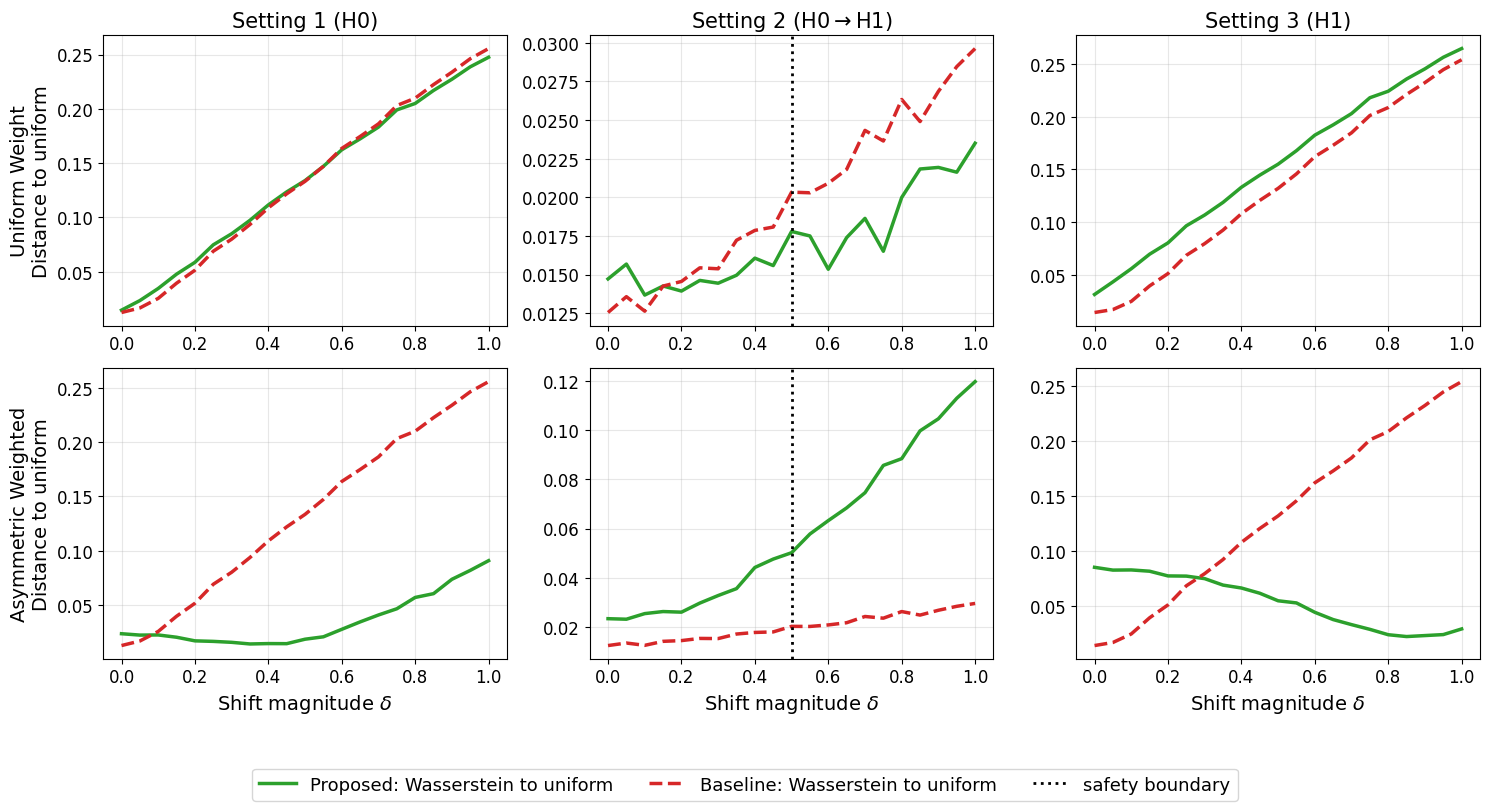

In [44]:

n_rows = len(loss_types)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows), sharex=False, sharey=False)

if n_rows == 1:
    axes = np.array([axes])

for row_idx, loss_type in enumerate(loss_types):
    df1, df2, df3, run_dir = load_triplet(seed, lr, lambda_mmd, loss_type,tau=tau)

    for col_idx, (ax, df, title) in enumerate(zip(axes[row_idx], [df1, df2, df3], titles)):
        delta = df["delta"].to_numpy()

        mmd_prop = df["mmd_u_prop"].apply(lambda x: np.mean(np.asarray(x))).to_numpy()
        mmd_base = df["mmd_u_base"].apply(lambda x: np.mean(np.asarray(x))).to_numpy()

        wass_prop = df["wass_u_prop"].apply(lambda x: np.mean(np.asarray(x))).to_numpy()
        wass_base = df["wass_u_base"].apply(lambda x: np.mean(np.asarray(x))).to_numpy()

        # ax.plot(delta, mmd_prop, lw=3, label="Proposed: MMD to uniform")
        # ax.plot(delta, mmd_base, lw=3, ls="--", label="Baseline: MMD to uniform")

        ax.plot(delta, wass_prop, lw=2.5, color="tab:green", label="Proposed: Wasserstein to uniform")
        ax.plot(delta, wass_base, lw=2.5, ls="--", color="tab:red", label="Baseline: Wasserstein to uniform")

        if title.startswith("Setting 2"):
            ax.axvline(0.5, color="black", ls=":", lw=2, label=("safety boundary" if row_idx == 0 else None))

        if row_idx == 0:
            ax.set_title(title, fontsize=title_fs)

        if row_idx == n_rows - 1:
            ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)

        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=tick_fs)

    axes[row_idx, 0].set_ylabel(f"{ylabel_list[row_idx]}\nDistance to uniform", fontsize=label_fs)

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=legend_fs,
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


Loaded from: results/diagnostics_results/seed_30_lr_0p003_lambda_mmd_0p01_loss_type_stability_asymmetric_recon_tau_1_perturb_type_cov_epochs_100_n_10000


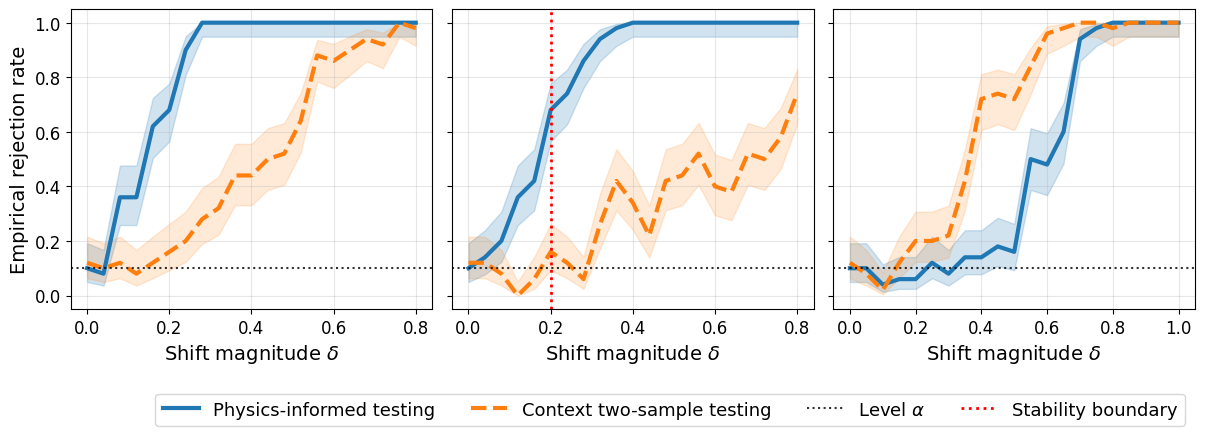

In [61]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


base = Path("results/diagnostics_results")
ylabel = "Empirical rejection rate"

def fmt(x):
    if isinstance(x, bool):
        return str(x).lower()
    if isinstance(x, float):
        return f"{x:g}".replace(".", "p")
    return str(x)

def build_run_dir(base, **config):
    parts = [f"{k}_{fmt(v)}" for k, v in config.items()]
    return base / "_".join(parts)

def load_triplet(base, **config):
    run_dir = build_run_dir(base, **config)
    df1 = pd.read_pickle(run_dir / "df1.pkl")
    df2 = pd.read_pickle(run_dir / "df2.pkl")
    df3 = pd.read_pickle(run_dir / "df3.pkl")
    return df1, df2, df3, run_dir

def wilson_band(series, alpha=0.1, ci_level=0.90):
    z_map = {
        0.90: 1.6448536269514722,
        0.95: 1.959963984540054,
        0.98: 2.3263478740408408,
        0.99: 2.5758293035489004,
    }
    z = z_map[round(ci_level, 2)]

    means, lowers, uppers = [], [], []
    for pvals in series:
        y = (np.asarray(pvals) <= alpha).astype(int)
        n = len(y)
        k = int(y.sum())

        phat = k / n
        denom = 1.0 + z**2 / n
        center = (phat + z**2 / (2 * n)) / denom
        radius = z * np.sqrt((phat * (1 - phat) / n) + (z**2 / (4 * n**2))) / denom

        means.append(phat)
        lowers.append(max(0.0, center - radius))
        uppers.append(min(1.0, center + radius))

    return np.array(means), np.array(lowers), np.array(uppers)

# Specify whatever is in the folder name, in order
# seed 12, 5, 8, 18
run_cfg = dict(
    seed=30,
    lr=3e-3,
    lambda_mmd=1e-2,
    loss_type="stability_asymmetric_recon",
    tau=1,
    perturb_type="cov",
    epochs=100,
    n=10000,
)

alpha = 0.1
boundary_delta = 0.2

titles = [
    r"Setting 1 ($H_0$)",
    r"Setting 2 ($H_0 \to H_1$)",
    r"Setting 3 ($H_1$)",
]

title_fs = 15
label_fs = 14
tick_fs = 12
legend_fs = 13

df1, df2, df3, run_dir = load_triplet(base, **run_cfg)
print("Loaded from:", run_dir)

subplot_right = 0.90
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True, sharex=False)

for col_idx, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles)):
    delta = df["delta"].to_numpy()

    rej_prop, prop_lo, prop_hi = wilson_band(df["pval"], alpha=alpha, ci_level=0.90)
    rej_base, base_lo, base_hi = wilson_band(df["pval_base"], alpha=alpha, ci_level=0.90)

    ax.fill_between(delta, prop_lo, prop_hi, alpha=0.20, color="#1f77b4")
    ax.fill_between(delta, base_lo, base_hi, alpha=0.16, color="#ff7f0e")

    ax.plot(delta, rej_prop, lw=3, color="#1f77b4", label="Physics-informed testing")
    ax.plot(delta, rej_base, lw=3, ls="--", color="#ff7f0e", label="Context two-sample testing")

    ax.axhline(
        alpha,
        color="k",
        ls=":",
        lw=1.5,
        alpha=0.8,
        label=(r"Level $\alpha$" if col_idx == 1 else None),
    )

    if col_idx == 1:
        ax.axvline(
            boundary_delta,
            color="red",
            ls=":",
            lw=2,
            label="Stability boundary",
        )

    # ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.tick_params(axis="both", labelsize=tick_fs)

axes[0].set_ylabel(ylabel, fontsize=label_fs)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05), fontsize=legend_fs)

fig.subplots_adjust(right=subplot_right, bottom=0.22)
plt.tight_layout(rect=[0, 0.08, subplot_right, 1])
plt.show()
